# Evaluación con LLM-as-judge

ROUGE mide solapamiento léxico, pero correlaciona mal con calidad percibida
por humanos. Usamos Qwen3-1.7B como juez automático para evaluar las
generaciones de los mejores modelos de V3 en tres dimensiones:

- **Coherencia (1-5):** estructura lógica, sin contradicciones ni repeticiones.
- **Fidelidad (1-5):** precisión respecto al artículo fuente, sin alucinaciones.
- **Fluidez (1-5):** gramática correcta, tono periodístico natural.

Se evalúan 50 muestras por modelo sobre el test subset.


In [1]:
# Setup
import sys
import os
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

from transformers import logging as hf_logging
hf_logging.set_verbosity_error()

import torch
import pandas as pd
from src.data.loader import load_config, load_cnn_dailymail
from src.evaluation.llm_judge import (
    init_judge, free_judge, judge_batch,
    results_to_dataframe, aggregate_scores,
)

cfg = load_config("../config/config.yaml")
dataset = load_cnn_dailymail(cfg)

FIGURES_DIR = Path("../results/figures")
TABLES_DIR = Path("../results/tables")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Generar resúmenes con los mejores modelos de V3

Cargamos el mejor checkpoint de T5 y Qwen3 identificados en V3.
**Ajustar los paths si la config ganadora fue distinta de A.**

In [2]:
# Load best T5 checkpoint.
from src.models.loader import load_model, LoadedModel
from src.evaluation.inference import generate_summaries
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

BEST_T5_DIR = "v3_t5_C"

t5_ckpt = Path(f"../results/checkpoints/{BEST_T5_DIR}")
# Find checkpoint subfolder
t5_subdirs = sorted([p for p in t5_ckpt.iterdir() if p.name.startswith("checkpoint-")])
t5_path = t5_subdirs[-1] if t5_subdirs else t5_ckpt

t5_model = AutoModelForSeq2SeqLM.from_pretrained(t5_path, dtype=torch.float32)
t5_tok = AutoTokenizer.from_pretrained(t5_path, use_fast=True)
t5_model.to("cuda").eval()

t5_loaded = LoadedModel(
    model=t5_model, tokenizer=t5_tok,
    name="google/flan-t5-base", model_type="seq2seq",
    max_input_length=cfg["models"]["t5"]["max_input_length"],
)

# Generate on the first 50 test samples (enough for LLM evaluation)
N_JUDGE = 50
test_sub = dataset["test"].select(range(N_JUDGE))
articles = test_sub["article"]
references = test_sub["highlights"]

t5_preds = generate_summaries(
    t5_loaded, articles,
    max_new_tokens=cfg["dataset"]["max_target_length"],
    num_beams=cfg["generation"]["num_beams"],
    batch_size=8,
)
print(f"T5 generated {len(t5_preds)} summaries")

# Free T5 VRAM before loading Qwen
del t5_model, t5_loaded
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

Generating [google/flan-t5-base]:   0%|          | 0/7 [00:00<?, ?it/s]

T5 generated 50 summaries


In [3]:
# Load best Qwen3 checkpoint.
from peft import PeftModel

BEST_QWEN_DIR = "v3_qwen_A"

qwen_base = load_model(cfg["models"]["qwen"])
qwen_ckpt = Path(f"../results/checkpoints/{BEST_QWEN_DIR}")
qwen_subdirs = sorted([p for p in qwen_ckpt.iterdir() if p.name.startswith("checkpoint-")])
qwen_path = qwen_subdirs[-1] if qwen_subdirs else qwen_ckpt

qwen_base.model = PeftModel.from_pretrained(qwen_base.model, str(qwen_path))
qwen_base.model.eval()
qwen_base.model.config.use_cache = True

qwen_preds = generate_summaries(
    qwen_base, articles,
    max_new_tokens=cfg["dataset"]["max_target_length"],
    num_beams=cfg["generation"]["num_beams"],
    batch_size=2,
)
print(f"Qwen3 generated {len(qwen_preds)} summaries")

del qwen_base
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

W0422 13:21:00.520000 5316 .venv\Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Generating [Qwen/Qwen3-1.7B]:   0%|          | 0/25 [00:00<?, ?it/s]

Qwen3 generated 50 summaries


## 2. Evaluación con Qwen3-1.7B

Evaluamos cada resumen con la versión sin LoRA como juez. De forma que evaluamos el fine-tuned con la versión generalista

In [4]:
# Load local judge model (Qwen3-1.7B base, not the LoRA version being evaluated)
judge_model, judge_tok = init_judge("Qwen/Qwen3-1.7B")

# Judge T5 summaries
print("Evaluating T5 summaries...")
t5_results = judge_batch(judge_model, judge_tok, list(articles), t5_preds,
                         model_label="Flan-T5-base")

# Judge Qwen3 summaries
print("\nEvaluating Qwen3 summaries...")
qwen_results = judge_batch(judge_model, judge_tok, list(articles), qwen_preds,
                           model_label="Qwen3-1.7B")

# Free judge VRAM
free_judge(judge_model, judge_tok)

# Combine and save
df_judge = results_to_dataframe(t5_results + qwen_results)
df_judge.to_csv(TABLES_DIR / "llm_judge_results.csv", index=False)
print(f"\nSaved {len(df_judge)} evaluations to llm_judge_results.csv")

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Judge model loaded: Qwen/Qwen3-1.7B (torch.bfloat16)
Evaluating T5 summaries...
  [Flan-T5-base] 10/50 (0 errors so far)
  [Flan-T5-base] 20/50 (0 errors so far)
  [Flan-T5-base] 30/50 (0 errors so far)
  [Flan-T5-base] 40/50 (0 errors so far)
  [Flan-T5-base] 50/50 (0 errors so far)

Evaluating Qwen3 summaries...
  [Qwen3-1.7B] 10/50 (0 errors so far)
  [Qwen3-1.7B] 20/50 (0 errors so far)
  [Qwen3-1.7B] 30/50 (0 errors so far)
  [Qwen3-1.7B] 40/50 (0 errors so far)
  [Qwen3-1.7B] 50/50 (0 errors so far)

Saved 100 evaluations to llm_judge_results.csv


In [5]:
# Aggregate scores per model
agg = aggregate_scores(df_judge)
print("\nAggregate LLM-judge scores:\n")
agg


Aggregate LLM-judge scores:



coherence             faithfulness             fluency        \
                  mean   std count         mean   std count    mean   std   
model                                                                       
Flan-T5-base      4.00  0.64    50         4.18  0.44    50    4.18  0.44   
Qwen3-1.7B        3.46  0.81    50         3.80  0.67    50    3.76  0.69   

                    
             count  
model               
Flan-T5-base    50  
Qwen3-1.7B      50

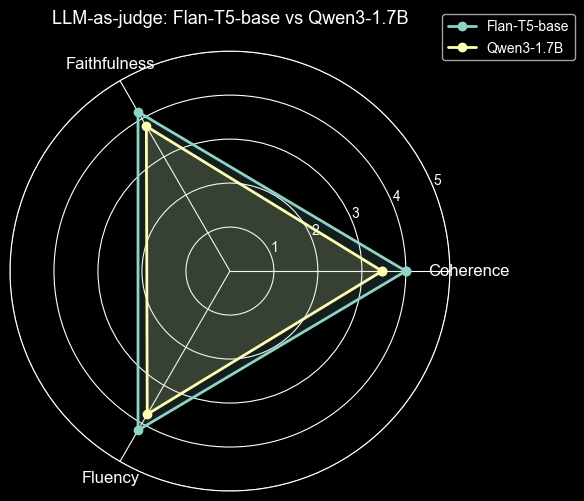

In [6]:
# Visualization: radar chart of mean scores by model
import matplotlib.pyplot as plt
import numpy as np

valid = df_judge[df_judge["error"] == ""].copy()
means = valid.groupby("model")[["coherence", "faithfulness", "fluency"]].mean()

categories = ["Coherence", "Faithfulness", "Fluency"]
N = len(categories)
angles = [n / N * 2 * np.pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

for model_name, row in means.iterrows():
    values = list(row.values) + [row.values[0]]
    ax.plot(angles, values, "o-", linewidth=2, label=model_name)
    ax.fill(angles, values, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
ax.set_title("LLM-as-judge: Flan-T5-base vs Qwen3-1.7B", fontsize=13, pad=20)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "llm_judge_radar.png", bbox_inches="tight", dpi=120)
plt.show()

In [7]:
# Show a few examples with low faithfulness (potential hallucinations)
low_faith = valid[valid["faithfulness"] <= 2].sort_values("faithfulness")
print(f"Summaries with faithfulness <= 2: {len(low_faith)}\n")

for _, row in low_faith.head(3).iterrows():
    idx = int(row["index"])
    model = row["model"]
    pred = t5_preds[idx] if "T5" in model else qwen_preds[idx]
    print(f"[{model}] idx={idx}, scores: C={row['coherence']} F={row['faithfulness']} Fl={row['fluency']}")
    print(f"Justification: {row['justification']}")
    print(f"Summary: {pred[:300]}")
    print("-" * 80)

Summaries with faithfulness <= 2: 2

[Qwen3-1.7B] idx=2, scores: C=1 F=1 Fl=1
Justification: The summary is disjointed and contains incorrect information, such as the claim that Zarif was born to a traditional family with an unspecified birth date and that he has been accused of running a charitable foundation. These inaccuracies and lack of logical flow make the summary poor.
Summary: Six facts about Iran's foreign minister that you might not know .
Mohammad Zarif is the foreign minister of the Islamic Republic of Iran .
Zarif was born to a traditional family, but his birth date is not agreed upon .
He has been accused of running a charitable foundation for Iran's government .
--------------------------------------------------------------------------------
[Qwen3-1.7B] idx=16, scores: C=3 F=2 Fl=4
Justification: The summary is logically organized but lacks key details from the article. It mentions the 'Strike Hard' campaign and the global trend of rising death penalty use, but omits s

## Análisis del LLM-as-judge

### Puntuaciones medias (1-5)

| Modelo       | Coherencia | Fidelidad | Fluidez |
|--------------|------------|-----------|---------|
| Flan-T5-base | **4.00**   | **4.18**  | **4.18** |
| Qwen3-1.7B   | 3.46       | 3.80      | 3.76    |

### Flan-T5-base gana en las tres dimensiones

Un resultado que contradice parcialmente la narrativa de ROUGE: aunque Qwen3
supera a T5 en ROUGE-Lsum (27.75 vs 27.35), el juez automático lo puntúa
significativamente peor en las tres dimensiones cualitativas. Las diferencias
más marcadas:

- **Coherencia (4.00 vs 3.46, Δ=0.54):** T5 genera resúmenes más estructurados
  y sin contradicciones internas. Esto es coherente con su arquitectura
  encoder-decoder, diseñada para mantener consistencia entre entrada y salida
  a través del cross-attention.

- **Fidelidad (4.18 vs 3.80, Δ=0.38):** T5 produce menos alucinaciones.
  De los 2 resúmenes con faithfulness ≤ 2 en todo el dataset, ambos son de
  Qwen3. Ejemplo: el juez detectó que Qwen3 inventó que Zarif "ha sido acusado
  de dirigir una fundación benéfica" — información no presente en el artículo.

- **Fluidez (4.18 vs 3.76, Δ=0.42):** T5 produce texto más natural y
  gramaticalmente correcto. Qwen3 tiende a generar frases más telegráficas
  (estilo "NEW: X . Y . Z .") que, aunque efectivas para ROUGE, suenan
  menos naturales.

### ROUGE vs LLM-judge: métricas complementarias, no sustitutas

Este análisis confirma que **ROUGE no captura la calidad percibida**. Qwen3
obtiene ROUGE-Lsum superior a T5 (27.75 vs 27.35) pero puntuaciones inferiores
en las tres dimensiones del juez. Esto se explica porque:

1. ROUGE mide solapamiento léxico (n-gramas coincidentes), no coherencia lógica.
2. El estilo telegráfico de Qwen3 ("NEW: X . Y .") maximiza ROUGE-Lsum
   (coincidencias frase a frase) pero penaliza la lectura natural.
3. Las alucinaciones no afectan a ROUGE si no aparecen en la referencia
   (simplemente se ignoran), pero el juez sí las penaliza.

**Conclusión:** para evaluaciones rigurosas de summarization, ROUGE y LLM-judge
deben usarse juntos. ROUGE como filtro cuantitativo rápido, LLM-judge para
validación cualitativa del top de modelos.

### Limitaciones del juez

El juez es Qwen3-1.7B base (no la versión LoRA fine-tuneada). Aunque
metodológicamente aceptable (juez ≠ modelo evaluado), un modelo más grande
(GPT-4, Gemini Pro) daría evaluaciones más fiables. Las puntuaciones deben
interpretarse como una **aproximación relativa** entre modelos, no como
valoraciones absolutas de calidad.